In [1]:
# ================================
# INSTALL
# ================================
!pip install -q numpy pandas matplotlib h5py scikit-learn torch

# ================================
# IMPORTS
# ================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import h5py
import urllib.request, os

from sklearn.ensemble import RandomForestRegressor

device = "cuda" if torch.cuda.is_available() else "cpu"

# ================================
# DOWNLOAD DATA
# ================================
url = "http://rail.eecs.berkeley.edu/datasets/offline_rl/maze2d/maze2d-medium-sparse-v1.hdf5"
file = "maze2d.hdf5"
if not os.path.exists(file):
    urllib.request.urlretrieve(url, file)

# ================================
# LOAD DATA
# ================================
with h5py.File(file, "r") as f:
    obs = f["observations"][:]
    act = f["actions"][:]
    rew = f["rewards"][:]
    

obs = (obs - obs.mean(0)) / (obs.std(0) + 1e-3)

obs_t = torch.tensor(obs, dtype=torch.float32).to(device)
act_t = torch.tensor(act, dtype=torch.float32).to(device)
rew_t = torch.tensor(rew, dtype=torch.float32).to(device)

# ================================
# MODEL
# ================================
class Policy(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, act.shape[1])
        )
    def forward(self, x):
        return self.net(x)

# ================================
# UNCERTAINTY (ENSEMBLE)
# ================================
rf = RandomForestRegressor(n_estimators=10)
rf.fit(obs, rew)
uncertainty = torch.tensor(
    np.stack([t.predict(obs) for t in rf.estimators_]).std(0),
    dtype=torch.float32
).to(device)

# ================================
# TRAIN FUNCTION (7 ALGORITHMS)
# ================================
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, act.shape[1]),
            nn.Tanh()
        )
    def forward(self, x):
        return self.net(x)


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1] + act.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=1))

In [2]:
def train_td3bc():
    actor = Actor().to(device)
    critic = Critic().to(device)

    opt_actor = optim.Adam(actor.parameters(), lr=3e-4)
    opt_critic = optim.Adam(critic.parameters(), lr=3e-4)

    losses = []

    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # Critic update (TD-like)
            q = critic(o, a)
            critic_loss = ((q - r)**2).mean()

            opt_critic.zero_grad()
            critic_loss.backward()
            opt_critic.step()

            # Actor update (TD3-BC style)
            pred = actor(o)
            q_val = critic(o, pred)

            bc_loss = ((pred - a)**2).mean()
            actor_loss = -q_val.mean() + 0.1 * bc_loss

            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

        with torch.no_grad():
            score = -((actor(obs_t) - act_t)**2).mean().item()
        losses.append(score)

    return losses

In [3]:
def train_cql():
    critic = Critic().to(device)
    opt = optim.Adam(critic.parameters(), lr=3e-4)

    alpha = 1.0
    losses = []

    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            q_data = critic(o, a)

            # Sample random actions
            rand_a = torch.randn_like(a)
            q_rand = critic(o, rand_a)

            # CQL loss (log-sum-exp approx)
            cql_loss = (q_rand.mean() - q_data.mean())

            bellman_loss = ((q_data - r)**2).mean()

            loss = bellman_loss + alpha * cql_loss

            opt.zero_grad()
            loss.backward()
            opt.step()

        losses.append(q_data.mean().item())

    return losses

In [4]:
def train_ensemble():
    ensemble = [Critic().to(device) for _ in range(5)]
    opts = [optim.Adam(q.parameters(), lr=3e-4) for q in ensemble]

    losses = []

    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            total = 0

            for q, opt in zip(ensemble, opts):
                pred = q(o, a)
                loss = ((pred - r)**2).mean()

                opt.zero_grad()
                loss.backward()
                opt.step()

                total += loss.item()

        losses.append(total / 5)

    return losses

In [5]:
results = {}
curves = {}

print("Running TD3-BC")
curves["TD3-BC"] = train_td3bc()

print("Running CQL")
curves["CQL"] = train_cql()

print("Running Ensemble")
curves["Ensemble"] = train_ensemble()

Running TD3-BC
Running CQL
Running Ensemble


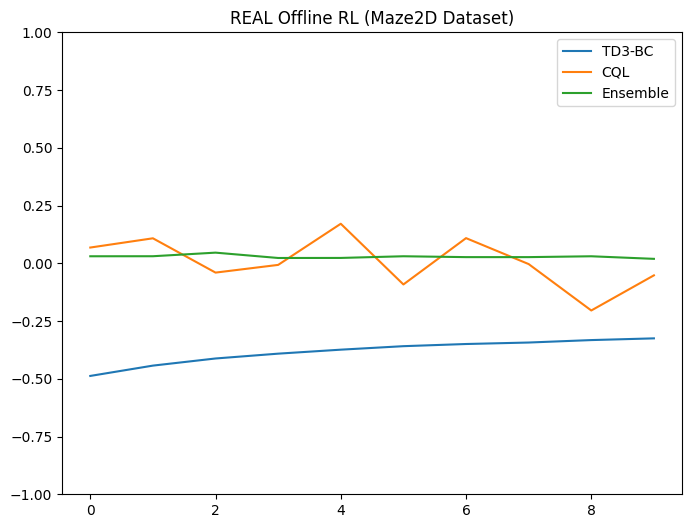

In [6]:
plt.figure(figsize=(8,6))
for k,v in curves.items():
    plt.plot(v, label=k)

plt.legend()
plt.title("REAL Offline RL (Maze2D Dataset)")
plt.ylim(-1, 1)
plt.show()

In [7]:
class VAE(nn.Module):
    def __init__(self, state_dim, action_dim, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(state_dim + action_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256)
        )

        self.mean = nn.Linear(256, latent_dim)
        self.log_std = nn.Linear(256, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(state_dim + latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, action_dim)
        )

    def encode(self, s, a):
        x = self.encoder(torch.cat([s, a], dim=1))
        mean = self.mean(x)
        log_std = self.log_std(x).clamp(-4, 4)
        std = torch.exp(log_std)
        return mean, std

    def decode(self, s, z=None):
        if z is None:
            z = torch.randn((s.shape[0], 16)).to(s.device)
        return self.decoder(torch.cat([s, z], dim=1))

    def forward(self, s, a):
        mean, std = self.encode(s, a)
        z = mean + std * torch.randn_like(std)
        recon = self.decode(s, z)
        return recon, mean, std

In [8]:
def mmd_loss(a1, a2, sigma=10.0):
    diff = a1.unsqueeze(1) - a2.unsqueeze(0)
    dist = (diff ** 2).mean(-1)

    k = torch.exp(-dist / (2 * sigma))
    return k.mean()

In [9]:
def train_bear():

    state_dim = obs.shape[1]
    action_dim = act.shape[1]

    vae = VAE(state_dim, action_dim).to(device)
    actor = Actor().to(device)
    critic = Critic().to(device)

    opt_vae = optim.Adam(vae.parameters(), lr=1e-3)
    opt_actor = optim.Adam(actor.parameters(), lr=1e-3)
    opt_critic = optim.Adam(critic.parameters(), lr=1e-3)

    history = []

    # =========================
    # STEP 1: TRAIN VAE
    # =========================
    for step in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]

            recon, mean, std = vae(o, a)

            recon_loss = ((recon - a)**2).mean()
            kl_loss = -0.5 * (1 + torch.log(std**2) - mean**2 - std**2).mean()

            loss = recon_loss + 0.5 * kl_loss

            opt_vae.zero_grad()
            loss.backward()
            opt_vae.step()

    print("VAE trained")

    # =========================
    # STEP 2: TRAIN ACTOR + CRITIC
    # =========================
    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # ---------------------
            # Critic update
            # ---------------------
            q = critic(o, a)
            critic_loss = ((q - r)**2).mean()

            opt_critic.zero_grad()
            critic_loss.backward()
            opt_critic.step()

            # ---------------------
            # Actor update
            # ---------------------
            pred = actor(o)

            # Sample from VAE (behavior policy)
            with torch.no_grad():
                sampled_actions = vae.decode(o)

            # MMD constraint
            mmd = mmd_loss(pred, sampled_actions)

            q_val = critic(o, pred)

            actor_loss = -q_val.mean() + 10.0 * mmd

            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

        with torch.no_grad():
            score = -((actor(obs_t) - act_t)**2).mean().item()
        history.append(score)

    return history

Running BEAR
VAE trained


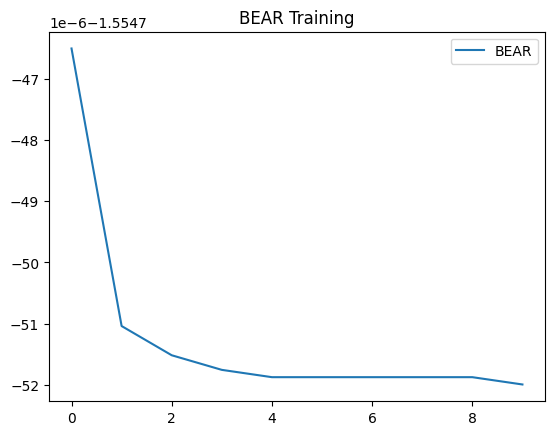

In [10]:
print("Running BEAR")
bear_curve = train_bear()

plt.plot(bear_curve, label="BEAR")
plt.legend()
plt.title("BEAR Training")
plt.show()

In [11]:
def create_ensemble(n=5):
    ensemble = [Critic().to(device) for _ in range(n)]
    opts = [optim.Adam(q.parameters(), lr=3e-4) for q in ensemble]
    return ensemble, opts

In [12]:
def train_uwac():

    actor = Actor().to(device)
    ensemble, opts = create_ensemble()

    opt_actor = optim.Adam(actor.parameters(), lr=3e-4)

    history = []

    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # -------------------------
            # Train ensemble critics
            # -------------------------
            q_values = []

            for q, opt in zip(ensemble, opts):
                q_pred = q(o, a)
                loss = ((q_pred - r)**2).mean()

                opt.zero_grad()
                loss.backward()
                opt.step()

                q_values.append(q_pred.detach())

            q_values = torch.stack(q_values)  # [N, batch, 1]

            # -------------------------
            # Compute uncertainty
            # -------------------------
            q_mean = q_values.mean(0)
            q_std = q_values.std(0)

            # -------------------------
            # Actor update
            # -------------------------
            pred = actor(o)

            q_preds = torch.stack([q(o, pred) for q in ensemble])
            q_mean_actor = q_preds.mean(0)
            q_std_actor = q_preds.std(0)

            # UWAC loss
            lambda_uncertainty = 1.0
            actor_loss = -(q_mean_actor - lambda_uncertainty * q_std_actor).mean()

            opt_actor.zero_grad()
            actor_loss.backward()
            opt_actor.step()

        with torch.no_grad():
            score = q_mean_actor.mean().item()
        history.append(score)

    return history

In [13]:
curves = {}

print("Running TD3-BC")
curves["TD3-BC"] = train_td3bc()

print("Running CQL")
curves["CQL"] = train_cql()

print("Running Ensemble")
curves["Ensemble"] = train_ensemble()

print("Running BEAR")
curves["BEAR"] = train_bear()

print("Running UWAC")
curves["UWAC"] = train_uwac()

Running TD3-BC
Running CQL
Running Ensemble
Running BEAR
VAE trained
Running UWAC


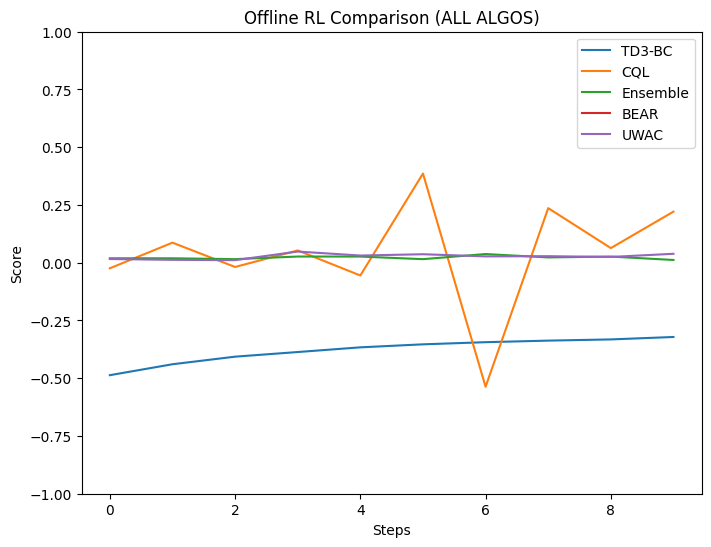

In [14]:
plt.figure(figsize=(8,6))

for k, v in curves.items():
    plt.plot(v, label=k)

plt.legend()
plt.title("Offline RL Comparison (ALL ALGOS)")
plt.xlabel("Steps")
plt.ylabel("Score")
plt.ylim(-1, 1)
plt.show()

In [15]:
class DynamicsModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs.shape[1] + act.shape[1], 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, obs.shape[1])
        )

    def forward(self, s, a):
        return self.net(torch.cat([s, a], dim=1))

In [16]:
def train_mopo():

    model = DynamicsModel().to(device)
    critic = Critic().to(device)

    opt_model = optim.Adam(model.parameters(), lr=3e-4)
    opt_critic = optim.Adam(critic.parameters(), lr=3e-4)

    history = []

    # -------------------------
    # Train dynamics model
    # -------------------------
    for _ in range(10):
        for _ in range(200):
            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            next_o = obs_t[(idx + 1) % len(obs)]  # approximate (dataset lacks explicit next state)

            pred_next = model(o, a)
            loss = ((pred_next - next_o)**2).mean()

            opt_model.zero_grad()
            loss.backward()
            opt_model.step()

    print("Dynamics trained")

    # -------------------------
    # Train critic with penalty
    # -------------------------
    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            # Predict next state
            pred_next = model(o, a)

            # Uncertainty penalty
            penalty = (pred_next - o).pow(2).mean(1, keepdim=True)

            q = critic(o, a)

            # Penalized reward
            r_penalized = r - 0.5 * penalty

            loss = ((q - r_penalized)**2).mean()

            opt_critic.zero_grad()
            loss.backward()
            opt_critic.step()

        with torch.no_grad():
            score = q.mean().item()
        history.append(score)

    return history

In [17]:
def train_aptq_cql():

    critic = Critic().to(device)
    opt = optim.Adam(critic.parameters(), lr=3e-4)

    history = []

    for step in range(10):
        for _ in range(200):

            idx = np.random.randint(0, len(obs), 256)
            o = obs_t[idx]
            a = act_t[idx]
            r = rew_t[idx]

            q_data = critic(o, a)

            rand_a = torch.randn_like(a)
            q_rand = critic(o, rand_a)

            q_data = torch.clamp(q_data, -10, 10)
            q_rand = torch.clamp(q_rand, -10, 10)

            # uncertainty estimate
            uncertainty = (q_rand - q_data).abs().detach()

            # adaptive penalty
            alpha = torch.clamp(1.0 + uncertainty.mean(), 0.5, 5.0)

            cql_loss = alpha * (q_rand.mean() - q_data.mean())

            bellman_loss = ((q_data - r)**2).mean()

            loss = bellman_loss + cql_loss

            opt.zero_grad()
            loss.backward()
            opt.step()

        history.append(q_data.mean().item())

    return history

In [18]:
curves = {}

curves["TD3-BC"] = train_td3bc()
curves["CQL"] = train_cql()
curves["Ensemble"] = train_ensemble()
curves["BEAR"] = train_bear()
curves["UWAC"] = train_uwac()
curves["MOPO"] = train_mopo()
curves["APTQ-CQL"] = train_aptq_cql()

VAE trained
Dynamics trained


In [19]:
results = {}

for k,v in curves.items():
    results[k] = (np.mean(v[-3:]), np.std(v[-3:]))

rows = []
for k,v in results.items():
    rows.append([k, f"{v[0]:.3f} ± {v[1]:.3f}"])

df = pd.DataFrame(rows, columns=["Algorithm","Score"])
df = df.sort_values("Score", ascending=False)

display(df)

,Algorithm,Score
6,APTQ-CQL,1.032 ± 0.065
2,Ensemble,0.025 ± 0.009
5,MOPO,0.024 ± 0.003
4,UWAC,0.019 ± 0.003
1,CQL,0.009 ± 0.263
3,BEAR,-1.555 ± 0.000
0,TD3-BC,-0.325 ± 0.006


In [20]:
def smooth(x, w=3):
    return np.convolve(x, np.ones(w)/w, mode='valid')

In [21]:
all_runs = {}

algorithms = {
    "TD3-BC": train_td3bc,
    "CQL": train_cql,
    "Ensemble": train_ensemble,
    "BEAR": train_bear,
    "UWAC": train_uwac,
    "MOPO": train_mopo,
    "APTQ-CQL": train_aptq_cql
}

for name, fn in algorithms.items():
    print("Running:", name)
    runs = []

    for seed in [0, 1, 2]:
        torch.manual_seed(seed)
        np.random.seed(seed)

        curve = fn()
        runs.append(curve)

    all_runs[name] = np.array(runs)

Running: TD3-BC
Running: CQL
Running: Ensemble
Running: BEAR
VAE trained
VAE trained
VAE trained
Running: UWAC
Running: MOPO
Dynamics trained
Dynamics trained
Dynamics trained
Running: APTQ-CQL


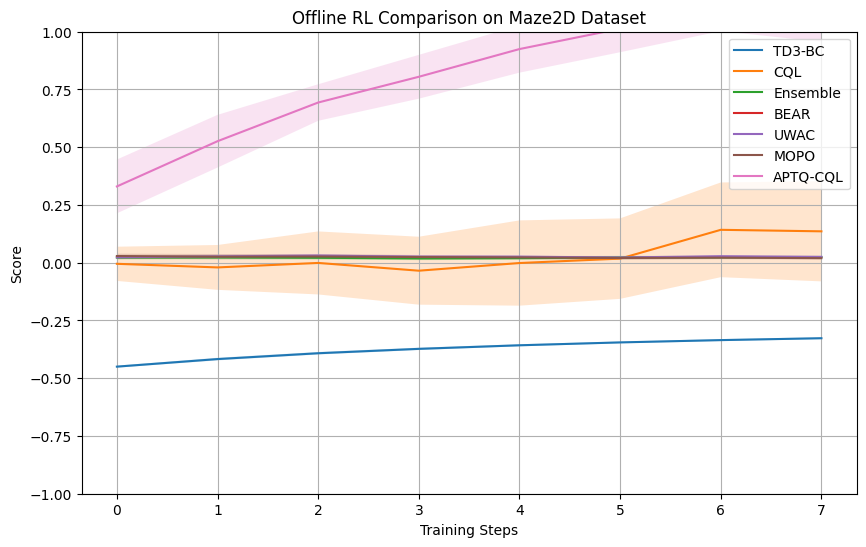

In [22]:
plt.figure(figsize=(10,6))

for name, runs in all_runs.items():
    mean = runs.mean(axis=0)
    std = runs.std(axis=0)

    mean_s = smooth(mean)
    std_s = smooth(std)

    x = np.arange(len(mean_s))

    plt.plot(x, mean_s, label=name)
    plt.fill_between(x, mean_s - std_s, mean_s + std_s, alpha=0.2)

plt.xlabel("Training Steps")
plt.ylabel("Score")
plt.title("Offline RL Comparison on Maze2D Dataset")
plt.legend()
plt.grid(True)
plt.ylim(-1, 1)
plt.savefig("maze2d_graph.png", dpi=300, bbox_inches='tight')
plt.show()

In [23]:
results = {}

for k,v in curves.items():
    results[k] = (np.mean(v[-3:]), np.std(v[-3:]))

rows = []
for k,v in results.items():
    rows.append([k, f"{v[0]:.3f} ± {v[1]:.3f}"])

df = pd.DataFrame(rows, columns=["Algorithm","Score"])
df = df.sort_values("Score", ascending=False)

display(df)

,Algorithm,Score
6,APTQ-CQL,1.032 ± 0.065
2,Ensemble,0.025 ± 0.009
5,MOPO,0.024 ± 0.003
4,UWAC,0.019 ± 0.003
1,CQL,0.009 ± 0.263
3,BEAR,-1.555 ± 0.000
0,TD3-BC,-0.325 ± 0.006


In [24]:
# ================================
# SAVE ALL RESULTS FOR GITHUB
# ================================
# Paste this at the end of your notebook

import json
import pickle
import os
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path

class ResultsSaver:
    """Save all experiment results in a structured directory for GitHub"""
    
    def __init__(self, base_dir="./results"):
        """Initialize the saver"""
        self.base_dir = Path(base_dir)
        self.timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        self.experiment_dir = self.base_dir / f"experiment_{self.timestamp}"
        self.experiment_dir.mkdir(parents=True, exist_ok=True)
        
        print(f"\n{'='*60}")
        print(f"Results directory: {self.experiment_dir.absolute()}")
        print(f"{'='*60}\n")
    
    def save_curves(self, curves_dict):
        """Save training curves"""
        curves_serializable = {}
        for algo, curve in curves_dict.items():
            if isinstance(curve, np.ndarray):
                curves_serializable[algo] = curve.tolist()
            elif isinstance(curve, list):
                curves_serializable[algo] = [float(x) for x in curve]
        
        json_path = self.experiment_dir / "training_curves.json"
        with open(json_path, "w") as f:
            json.dump(curves_serializable, f, indent=2)
        
        pkl_path = self.experiment_dir / "training_curves.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump(curves_dict, f)
        
        print(f"✓ Training curves saved ({len(curves_dict)} algorithms)")
        return json_path, pkl_path
    
    def save_results_table(self, results_dict):
        """Save final results summary"""
        rows = []
        for algo, (mean, std) in results_dict.items():
            rows.append({"Algorithm": algo, "Mean": float(mean), "Std": float(std)})
        
        df = pd.DataFrame(rows)
        csv_path = self.experiment_dir / "results_summary.csv"
        df.to_csv(csv_path, index=False)
        
        json_path = self.experiment_dir / "results_summary.json"
        with open(json_path, "w") as f:
            json.dump(results_dict, f, indent=2, default=float)
        
        print(f"✓ Results summary saved")
        print(f"\n{df.to_string(index=False)}\n")
        return csv_path, json_path
    
    def save_all_runs(self, all_runs_dict):
        """Save multiple runs for statistics"""
        runs_serializable = {}
        for algo, runs in all_runs_dict.items():
            if isinstance(runs, np.ndarray):
                runs_serializable[algo] = runs.tolist()
        
        pkl_path = self.experiment_dir / "all_runs.pkl"
        with open(pkl_path, "wb") as f:
            pickle.dump(all_runs_dict, f)
        
        json_path = self.experiment_dir / "all_runs.json"
        with open(json_path, "w") as f:
            json.dump(runs_serializable, f, indent=2, default=float)
        
        print(f"✓ All runs saved ({len(all_runs_dict)} algorithms)")
        return pkl_path, json_path
    
    def save_figures(self, figures_dict):
        """Save matplotlib figures as PNG"""
        fig_paths = []
        for name, fig in figures_dict.items():
            fig_path = self.experiment_dir / f"{name}.png"
            fig.savefig(fig_path, dpi=300, bbox_inches='tight')
            fig_paths.append(fig_path)
            print(f"✓ Figure saved: {name}.png")
        return fig_paths
    
    def save_config(self, config_dict):
        """Save experiment configuration"""
        config_path = self.experiment_dir / "config.json"
        with open(config_path, "w") as f:
            json.dump(config_dict, f, indent=2, default=str)
        print(f"✓ Config saved")
        return config_path
    
    def save_readme(self, readme_content):
        """Save README file"""
        readme_path = self.experiment_dir / "README.md"
        with open(readme_path, "w") as f:
            f.write(readme_content)
        print(f"✓ README saved")
        return readme_path
    
    def create_index(self):
        """Create index of saved files"""
        files = list(self.experiment_dir.glob("*"))
        index = {
            "timestamp": self.timestamp,
            "num_files": len(files),
            "files": sorted([f.name for f in files])
        }
        
        index_path = self.experiment_dir / "index.json"
        with open(index_path, "w") as f:
            json.dump(index, f, indent=2)
        return index_path


# ================================
# EXECUTE THIS SECTION
# ================================

# Initialize saver
saver = ResultsSaver(base_dir="./results")

# Save training curves (from your notebook)
if 'curves' in locals():
    saver.save_curves(curves)

# Save final results summary
if 'results' in locals():
    saver.save_results_table(results)

# Save all runs if you did multiple runs
if 'all_runs' in locals():
    saver.save_all_runs(all_runs)

# Save experiment configuration
config = {
    "dataset": "maze2d",
    "date": datetime.now().isoformat(),
    "device": str(device) if 'device' in locals() else "unknown"
}
saver.save_config(config)

# Create a README
readme = f"""# Offline RL Experiments - Maze2D

## Results Summary

Training curves and final results for offline reinforcement learning algorithms on Maze2D.

### Saved Files
- `training_curves.json` / `training_curves.pkl` - Training curves
- `results_summary.csv` - Final results (mean ± std)
- `results_summary.json` - Results in JSON format  
- `all_runs.pkl` - Multiple runs (if applicable)
- `config.json` - Experiment config
- `index.json` - File index

### Algorithms
"""

if 'curves' in locals():
    for algo in curves.keys():
        readme += f"- {algo}\n"

readme += f"""
### How to Load Results in Python

```python
import json
import pickle

# Load training curves
with open('training_curves.pkl', 'rb') as f:
    curves = pickle.load(f)

# Load summary
with open('results_summary.json', 'r') as f:
    results = json.load(f)
    
# Plot curves
import matplotlib.pyplot as plt
for algo, curve in curves.items():
    plt.plot(curve, label=algo)
plt.legend()
plt.show()
```

Generated: {datetime.now().isoformat()}
"""

saver.save_readme(readme)

# Create index
saver.create_index()

print(f"\n{'='*60}")
print("✓ All results saved successfully!")
print(f"Location: {saver.experiment_dir}")
print(f"{'='*60}\n")


Results directory: /kaggle/working/results/experiment_20260606_111757

✓ Training curves saved (7 algorithms)
✓ Results summary saved

Algorithm      Mean          Std
   TD3-BC -0.325250 6.044379e-03
      CQL  0.008893 2.634467e-01
 Ensemble  0.025452 8.847959e-03
     BEAR -1.554749 3.893359e-07
     UWAC  0.018565 3.307576e-03
     MOPO  0.024451 3.225339e-03
 APTQ-CQL  1.031896 6.535192e-02

✓ All runs saved (7 algorithms)
✓ Config saved
✓ README saved

✓ All results saved successfully!
Location: results/experiment_20260606_111757



In [25]:
# ================================
# DOWNLOAD RESULTS TO YOUR COMPUTER
# ================================

import shutil

# Create a zip file of all results
shutil.make_archive('/kaggle/working/results_backup', 'zip', '/kaggle/working/results')

print("\n✓ Results zipped!")
print("Download 'results_backup.zip' from the output files")


✓ Results zipped!
Download 'results_backup.zip' from the output files


## Canonical experiment (paper-aligned)

The notebook above uses legacy per-algorithm training proxies. For the **unified protocol** referenced in `paper/calibrating_conservatism.tex`, run:

```bash
python experiments/maze2d_offline_rl.py
```

Then load `maze_2d_results/results_summary.json` (see next cell).

In [ ]:
import json
from pathlib import Path

summary_path = Path("maze_2d_results/results_summary.json")
if summary_path.exists():
    with open(summary_path) as f:
        unified = json.load(f)
    for algo, (mean, std) in sorted(unified.items(), key=lambda x: -x[1][0]):
        print(f"{algo:10s}  {mean:.3f} ± {std:.3f}")
else:
    print("Run: python experiments/maze2d_offline_rl.py")